In [1]:
%load_ext autoreload
%autoreload 2

# Load the BPMN Dataset

In [2]:
from mcp4cm.bpmn.dataloading import BPMNDataset
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType


In [3]:
bpmn_dataset = load_dataset(dataset_type=DatasetType.BPMNMODELSET, path='data/bpmnmodelset')


Loading SAP SAM Dataset @ data/bpmnmodelset\sap_sam_2022/models:   0%|          | 0/103 [00:00<?, ?it/s]

Defining file path for saving dataset and loading it later on.

In [4]:
file_path = 'data/bpmnmodelset/processed/culled_models.csv'


In [5]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models

use_types = False

if use_types:
    key = 'names_with_types'
    file_path = 'data/bpmnmodelset/processed/culled_with_typed_names.csv'
    empty_name = 'unknown type: empty name'
else:
    key = 'names'
    file_path = 'data/bpmnmodelset/processed/culled_with_names.csv'
    empty_name = 'empty name'



extract_names_from_models(bpmn_dataset, use_types=use_types)


Extracting names from raw model done.


In [6]:
len(bpmn_dataset)

30312

In [7]:
from mcp4cm.bpmn.data_extraction import (filter_empty_models,
                                         filter_models_by_element_count,
                                         filter_models_by_empty_name_percentage,
                                         filter_models_by_dummy_words)
from mcp4cm.dataloading import Dataset

print(bpmn_dataset)
Dataset.apply_filters(
    dataset=bpmn_dataset,
    filters=[
        filter_empty_models,
        filter_models_by_element_count,
        filter_models_by_empty_name_percentage,
        filter_models_by_dummy_words
    ],
)

print(bpmn_dataset)

Dataset(name=sapsam_2022_bpmn2, models=30312)
Found models with empty names: 808
Filtered out models with element counts outside of 5 and 200: 408
Filtered out models with a empty name percentage higher than 0.5: 14757
Filtered out models with a dummy_percentage higher than 0.6: 4
Dataset(name=sapsam_2022_bpmn2, models=14335)


In [8]:
from mcp4cm.language_detection import detect_dataset_languages
from mcp4cm.bpmn.data_extraction import extract_model_languages

extract_model_languages(bpmn_dataset, key=key, empty_name=empty_name)


Language Extraction Progress:   0%|          | 0/14335 [00:00<?, ?it/s]

In [9]:
language_dict = detect_dataset_languages(bpmn_dataset)

Language Distribution Across Models:
Language: en, Count: 8764
Language: de, Count: 3579
Language: nl, Count: 104
Language: fr, Count: 205
Language: hr, Count: 145
Language: sl, Count: 129
Language: es, Count: 454
Language: ro, Count: 91
Language: pl, Count: 27
Language: it, Count: 286
Language: pt, Count: 144
Language: el, Count: 35
Language: et, Count: 150
Language: sv, Count: 64
Language: ja, Count: 6
Language: ru, Count: 5
Language: hu, Count: 21
Language: th, Count: 1
Language: so, Count: 1
Language: af, Count: 11
Language: id, Count: 66
Language: fi, Count: 8
Language: tr, Count: 15
Language: da, Count: 6
Language: cs, Count: 4
Language: fa, Count: 1
Language: zh-cn, Count: 1
Language: ca, Count: 2
Language: vi, Count: 2
Language: no, Count: 1
Language: lt, Count: 1
Language: sk, Count: 2
Language: ko, Count: 1
Language: cy, Count: 1
Language: sq, Count: 2


In [10]:
from mcp4cm.language_detection import filter_models_by_language
english_dataset = filter_models_by_language(bpmn_dataset, 'en', key=key, empty_name=empty_name)
language_dict = detect_dataset_languages(english_dataset)

file_path = 'data/bpmnmodelset/processed/english_models.csv'
print(len(english_dataset))
BPMNDataset.to_csv(english_dataset, file_path);


Language Distribution Across Models:
Language: en, Count: 8762
8762


In [11]:
del(english_dataset)

In [12]:
from mcp4cm.bpmn.dataloading import load_dataset_from_csv

file_path = 'data/bpmnmodelset/processed/english_models.csv'
loaded_dataset = load_dataset_from_csv('english_bpmn', fp=file_path)

In [13]:
len(loaded_dataset)

8762


=== Dataset Statistics ===
Duplicate Detection on already computed hashes took 0.00 seconds.
Total number of models: 8762
Total unique files: 3859
Total duplicate files: 4903
Number of duplicate groups: 45


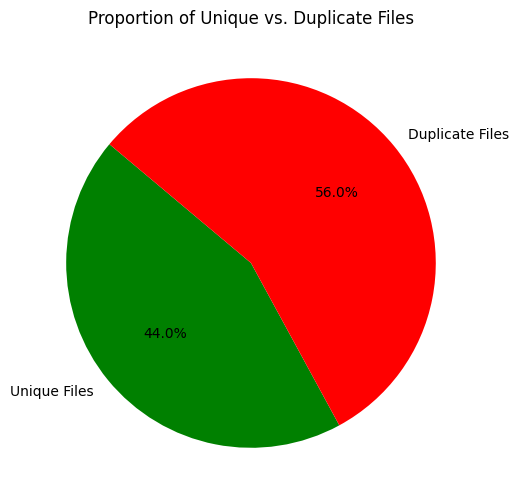

(Dataset(name=english_bpmn_unique, models=3859),
 Dataset(name=english_bpmn_duplicates, models=4903))

In [14]:
from mcp4cm.duplicate_detection import detect_duplicates_by_hash
detect_duplicates_by_hash(loaded_dataset, inplace=False, plt_fig=True, print_results=True)


Generating Connectivity Graph
Connectivity Graph Done
Calculating connected Components
Calculating connected Components Done
Number of components: 3475
Finding unique files:
Creating Duplicate Groups

=== Dataset Statistics ===
Total files processed: 8762
Total unique files: 3310
Total duplicate files: 5452
Number of duplicate groups: 165


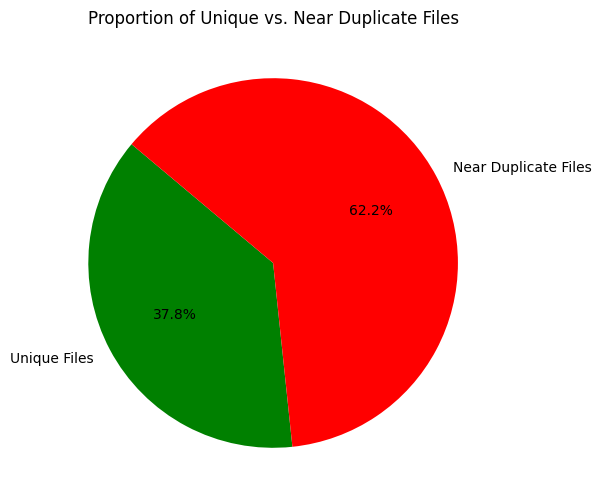

In [15]:
from mcp4cm.duplicate_detection import tfidf_near_duplicate_detector
key = 'names'
_, duplicate_dataset = tfidf_near_duplicate_detector(loaded_dataset,key=key, threshold=0.95, inplace=False, plt_fig=True, print_results=True)

In [16]:
file_path = 'data/bpmnmodelset/processed/english_deduplicated_models.csv'
BPMNDataset.to_csv(loaded_dataset, file_path);

In [17]:
duplicate_file_path = 'data/bpmnmodelset/processed/duplicate_models.csv'
BPMNDataset.to_csv(duplicate_dataset, duplicate_file_path);

In [18]:
duplicate_dataset.models.value_counts('duplicate_group')

duplicate_group
2       1618
0       1615
4       1562
33       107
109       26
        ... 
2838       2
2884       2
2891       2
3047       2
3184       2
Name: count, Length: 165, dtype: int64

In [24]:
print(duplicate_dataset.models.query('duplicate_group == 109').iloc[0].names)
print(duplicate_dataset.models.query('duplicate_group == 109').iloc[20].names)

['empty name', 'empty name', 'Accept Choice 90%', 'Reject  Choice 10%', 'Not eligible 25%', 'Yes, eligible 75%', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'Government Website UEN', 'Industrial Management System', 'Industrial Management System', 'Rental Application Form', 'Rental Application Form', 'Rental Application Form', 'Rental Application Form', 'Rental Application Form', 'Rental Application Form', 'Booking fee', 'Rental receipt', 'Rental Application Form', 'Rental Application Form', 'StarMall', 'Marketing Officer', 'MO emails LM for Rental Application approval', 'Process end', 'Customer  Decision?', 'Process end', 'Eligible Customer?', 'MO reserves customer selection in IMS and updates renta